
--- Task: two_gaussians ---
Grad Check for two_gaussians: Difference = 1.00e-08
Beginning descent for two_gaussians...
  Iteration 0 | Loss: 0.6178
  Iteration 500 | Loss: 0.1202
  Iteration 1000 | Loss: 0.1198
  Iteration 1500 | Loss: 0.1196
>> two_gaussians Accuracy: 91.50%

------------------------------
Hyperparameters for two_gaussians
------------------------------
Dataset               : two_gaussians
Hidden Nodes (k)      : 9
Learning Rate         : 0.5
Epochs (Iterations)   : 2000
Optimizer             : Gradient Descent (Manual)
Loss Function         : Cross-Entropy
Hidden Activation     : Tanh
Output Activation     : Softmax
------------------------------



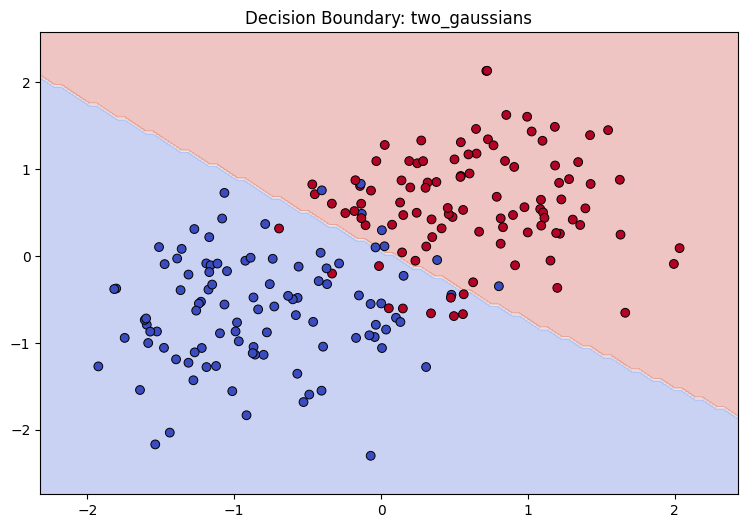


--- Task: xor ---
Grad Check for xor: Difference = 1.62e-08
Beginning descent for xor...
  Iteration 0 | Loss: 0.7034
  Iteration 500 | Loss: 0.1028
  Iteration 1000 | Loss: 0.0708
  Iteration 1500 | Loss: 0.0537
>> xor Accuracy: 97.50%

------------------------------
Hyperparameters for xor
------------------------------
Dataset               : xor
Hidden Nodes (k)      : 9
Learning Rate         : 0.5
Epochs (Iterations)   : 2000
Optimizer             : Gradient Descent (Manual)
Loss Function         : Cross-Entropy
Hidden Activation     : Tanh
Output Activation     : Softmax
------------------------------



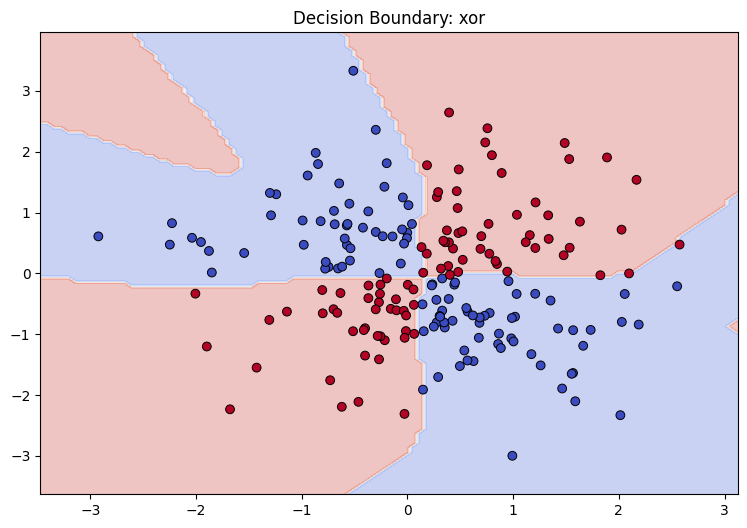


--- Task: center_surround ---
Grad Check for center_surround: Difference = 1.60e-08
Beginning descent for center_surround...
  Iteration 0 | Loss: 0.6668
  Iteration 500 | Loss: 0.2028
  Iteration 1000 | Loss: 0.1904
  Iteration 1500 | Loss: 0.1826
>> center_surround Accuracy: 75.50%

------------------------------
Hyperparameters for center_surround
------------------------------
Dataset               : center_surround
Hidden Nodes (k)      : 9
Learning Rate         : 0.5
Epochs (Iterations)   : 2000
Optimizer             : Gradient Descent (Manual)
Loss Function         : Cross-Entropy
Hidden Activation     : Tanh
Output Activation     : Softmax
------------------------------



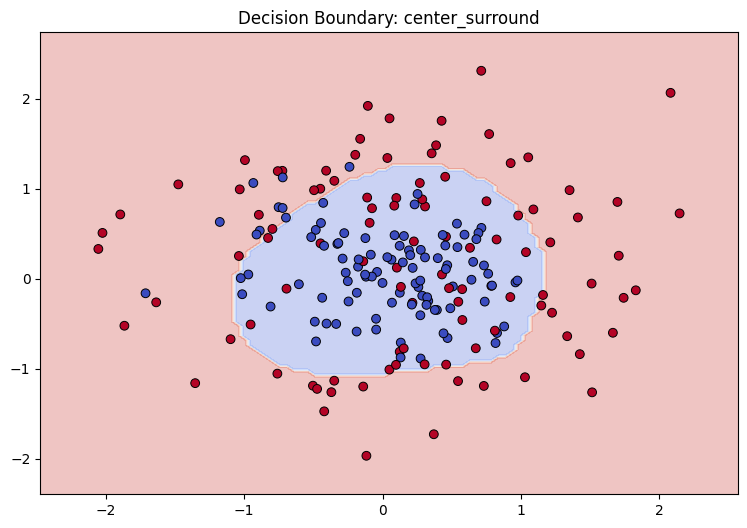


--- Task: spiral ---
Grad Check for spiral: Difference = 2.61e-08
Beginning descent for spiral...
  Iteration 0 | Loss: 0.7364
  Iteration 500 | Loss: 0.2137
  Iteration 1000 | Loss: 0.0685
  Iteration 1500 | Loss: 0.0405
>> spiral Accuracy: 100.00%

------------------------------
Hyperparameters for spiral
------------------------------
Dataset               : spiral
Hidden Nodes (k)      : 9
Learning Rate         : 0.5
Epochs (Iterations)   : 2000
Optimizer             : Gradient Descent (Manual)
Loss Function         : Cross-Entropy
Hidden Activation     : Tanh
Output Activation     : Softmax
------------------------------



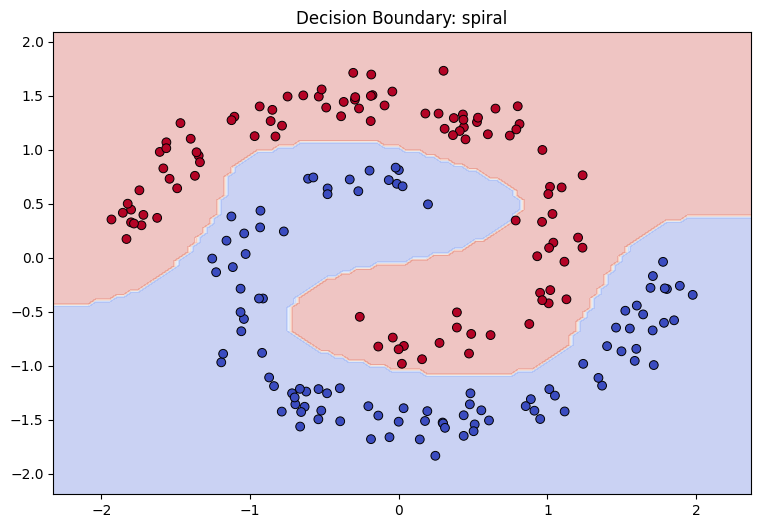

In [22]:
"""
Repeating Question 1 without PyTorch (using it only for weight initialization and calibration).
"""

import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

# Standard seed for consistency
np.random.seed(42)

def compute_softmax(z_scores):
    # Numerical stability hack: shift by max value
    max_val = np.max(z_scores, axis=1, keepdims=True)
    exp_scores = np.exp(z_scores - max_val)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

def layer_forward(inputs, W1, b1, W2, b2):
    # Layer 1: Linear -> Tanh
    pre_act1 = inputs @ W1 + b1
    hidden_out = np.tanh(pre_act1)
    
    # Layer 2: Linear -> Softmax
    pre_act2 = hidden_out @ W2 + b2
    predictions = compute_softmax(pre_act2)
    
    return predictions, hidden_out, pre_act1

def get_gradients(x_batch, targets, predictions, hidden, W2):
    batch_size = x_batch.shape[0]
    
    # Gradient of Cross-Entropy w.r.t final linear layer
    output_error = (predictions - targets) / batch_size
    
    # Gradients for the weight matrices and bias vectors
    dW2 = hidden.T @ output_error
    db2 = np.sum(output_error, axis=0)
    
    # Backprop through Tanh: (1 - hidden^2)
    hidden_error = (output_error @ W2.T) * (1 - hidden**2)
    
    dW1 = x_batch.T @ hidden_error
    db1 = np.sum(hidden_error, axis=0)
    
    return dW1, db1, dW2, db2

def execute_manual_training(dataset_id, nodes=9, learning_rate=0.5, iterations=2000):
    # 1. Load and Scale data locally
    train_data = pd.read_csv(f'{dataset_id}_train.csv')
    x_raw = train_data[['x1', 'x2']].values
    y_raw = train_data['label'].values
    
    avg = x_raw.mean(axis=0)
    dev = x_raw.std(axis=0)
    dev[dev == 0] = 1 # safety check
    x_scaled = (x_raw - avg) / dev
    
    # Create one-hot labels for the manual CE math
    one_hot_targets = np.eye(2)[y_raw.astype(int)]

    # 2. Use PyTorch to initialize weights so we can calibrate
    torch.manual_seed(42)
    ref_net = torch.nn.Sequential(
        torch.nn.Linear(2, nodes),
        torch.nn.Tanh(),
        torch.nn.Linear(nodes, 2)
    )
    
    # Stealing the exact starting weights/biases
    W1 = ref_net[0].weight.detach().numpy().T
    b1 = ref_net[0].bias.detach().numpy()
    W2 = ref_net[2].weight.detach().numpy().T
    b2 = ref_net[2].bias.detach().numpy()

    # --- Quick Gradient Check ---
    # Running a tiny batch through Torch to compare grads
    x_torch = torch.tensor(x_scaled[:10], dtype=torch.float32)
    y_torch = torch.tensor(y_raw[:10], dtype=torch.long)
    torch.nn.CrossEntropyLoss()(ref_net(x_torch), y_torch).backward()

    preds_c, h_c, _ = layer_forward(x_scaled[:10], W1, b1, W2, b2)
    dW1_c, _, _, _ = get_gradients(x_scaled[:10], one_hot_targets[:10], preds_c, h_c, W2)

    diff = np.abs(dW1_c.T - ref_net[0].weight.grad.numpy()).max()
    print(f"Grad Check for {dataset_id}: Difference = {diff:.2e}")
    
    # --- OPTIMIZATION LOOP ---
    print(f"Beginning descent for {dataset_id}...")
    for i in range(iterations):
        # Forward pass
        p, h, _ = layer_forward(x_scaled, W1, b1, W2, b2)
        
        # Calculate gradients
        dW1, db1, dW2, db2 = get_gradients(x_scaled, one_hot_targets, p, h, W2)
        
        # Manual GD update step
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        
        if i % 500 == 0:
            # Manual Cross-Entropy Loss
            loss = -np.mean(np.sum(one_hot_targets * np.log(p + 1e-12), axis=1))
            print(f"  Iteration {i} | Loss: {loss:.4f}")
    
    return (W1, b1, W2, b2), (avg, dev)


def visualize_results(x_test_raw, y_test, params, stats, title):
    W1, b1, W2, b2 = params
    avg, dev = stats
    
    # Normalize test points using training stats
    x_test_scaled = (x_test_raw - avg) / dev
    
    # Build grid window for decision map
    x0, x1 = x_test_scaled[:, 0].min(), x_test_scaled[:, 0].max()
    y0, y1 = x_test_scaled[:, 1].min(), x_test_scaled[:, 1].max()
    
    # Add some breathing room to the edges
    pad_x, pad_y = (x1 - x0) * 0.1, (y1 - y0) * 0.1
    
    res_x = np.linspace(x0 - pad_x, x1 + pad_x, 100)
    res_y = np.linspace(y0 - pad_y, y1 + pad_y, 100)
    mesh_x, mesh_y = np.meshgrid(res_x, res_y)
    coord_stack = np.c_[mesh_x.ravel(), mesh_y.ravel()]
    
    # Forward pass on the mesh grid
    grid_probs, _, _ = layer_forward(coord_stack, W1, b1, W2, b2)
    labels_grid = np.argmax(grid_probs, axis=1).reshape(mesh_x.shape)
    
    # Visual plotting
    plt.figure(figsize=(9, 6))
    plt.contourf(mesh_x, mesh_y, labels_grid, alpha=0.3, cmap='coolwarm')
    
    plt.scatter(x_test_scaled[:, 0], x_test_scaled[:, 1], c=y_test, 
                cmap='coolwarm', edgecolors='k', s=40, linewidths=0.7)
    
    plt.title(f"Decision Boundary: {title}")
    plt.show()

# --- RUN EXECUTION ---
datasets = ['two_gaussians', 'xor', 'center_surround', 'spiral']

for ds in datasets:
    print(f"\n--- Task: {ds} ---")
    hidden_nodes = 9
    learning_rate = 0.5
    num_epochs = 2000
    # Train and get parameters
    learned_params, data_stats = execute_manual_training(ds, nodes=9, learning_rate=0.5)
    
    # Validation step with Test CSV
    test_df = pd.read_csv(f'{ds}_test.csv')
    x_te_raw = test_df[['x1', 'x2']].values
    y_te = test_df['label'].values
    
    # Accurate scaling
    mu, sigma = data_stats
    x_te_scaled = (x_te_raw - mu) / sigma
    
    # Final check on accuracy
    final_probs, _, _ = layer_forward(x_te_scaled, *learned_params)
    final_preds = np.argmax(final_probs, axis=1)
    
    acc = np.mean(final_preds == y_te)
    print(f">> {ds} Accuracy: {acc * 100:.2f}%")

    config_summary = {
        'Dataset': ds,
        'Hidden Nodes (k)': hidden_nodes,
        'Learning Rate': learning_rate,
        'Epochs (Iterations)': num_epochs,
        'Optimizer': 'Gradient Descent (Manual)',
        'Loss Function': 'Cross-Entropy',
        'Hidden Activation': 'Tanh',
        'Output Activation': 'Softmax'
    }

    print("\n" + "-"*30)
    print(f"Hyperparameters for {ds}")
    print("-"*30)
    for key, val in config_summary.items():
        print(f"{key:<22}: {val}")
    print("-"*30 + "\n")
    
    # Generate visualization
    visualize_results(x_te_raw, y_te, learned_params, data_stats, ds)

While Questions 1 and 2 utilized a separate validation set to select the optimal k, this manual implementation fixes k=9 based on those prior findings. Consequently, the test dataset is used strictly for final generalization reporting rather than hyperparameter tuning. I leverage a key mathmatical simplification by combining the Softmax activation with the Cross-Entropy loss into a single expression. The gradient with respect to the logits or the output layer’s pre-activations simplifies to y − t, where y is the predicted class-probability vector and t is the one-hot encoded target.